c:\Users\U0152019\OneDrive - KU Leuven\PhD Documents\Projects\1. TabPFN\TabPFNCredit\.venv\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Project root: c:\Users\U0152019\OneDrive - KU Leuven\PhD Documents\Projects\1. TabPFN\TabPFNCredit

 COMPUTE MODE
  CUDA Available: False
  Device: CPU (forced)


 EXPERIMENT SMALL - Quick Benchmarking
  Row limit:       5000
  CV splits:       1
  Max epochs:      15
  HPO:             False
  Device:          CPU
  Excluded:        None

PD Datasets (1): ['0009.german']
LGD Datasets (1): ['0004.base_model']

PD Methods (17): ['catboost', 'knn', 'lightgbm', 'LogReg', 'NaiveBayes', 'RandomForest', 'svm', 'xgboost', 'NCM', 'dummy', 'tabpfn', 'tabpfn_v2', 'mlp', 'tabnet', 'resnet', 'ftt', 'tabr']
LGD Methods (12): ['catboost', 'knn', 'lightgbm', 'LinearRegression', 'RandomForest', 'xgboost', 'svm', 'tabpfn_v2', 'mlp', 'tabnet', 'resnet', 'ftt']


 Running PD Experiments
  Datasets: 1
  Methods:  17
  Total:    17 experiments
  Metric:   AUC



PD: 0009.german          + resnet         :  82%|████████▏ | 14/17 [00:53<00:09,  3.28s/it]

  ERROR: tabnet on 0009.german - Torch not compiled with CUDA enabled


PD: 0009.german          + tabr           : 100%|██████████| 17/17 [01:15<00:00,  4.42s/it]



 Running LGD Experiments
  Datasets: 1
  Methods:  12
  Total:    12 experiments
  Metric:   R2



LGD: 0004.base_model      + resnet         :  83%|████████▎ | 10/12 [02:35<00:37, 18.62s/it]

  ERROR: tabnet on 0004.base_model - Torch not compiled with CUDA enabled


LGD: 0004.base_model      + ftt            : 100%|██████████| 12/12 [03:09<00:00, 15.79s/it]



✓ All experiments completed!

 PD RESULTS (AUC)

             catboost       knn  lightgbm    LogReg  NaiveBayes  RandomForest       svm   xgboost       NCM  dummy  tabpfn  tabpfn_v2       mlp  tabnet   resnet       ftt     tabr
0009.german  0.764167  0.721607  0.770476  0.799762    0.768929      0.788929  0.800595  0.685774  0.780833    0.5     0.8   0.807738  0.791548     NaN  0.78369  0.749643  0.80619

 LGD RESULTS (R²)

                 catboost     knn  lightgbm  LinearRegression  RandomForest   xgboost       svm  tabpfn_v2       mlp  tabnet    resnet      ftt
0004.base_model  0.372665  0.1881  0.363723          0.198285       0.32725  0.261433  0.092615   0.318684  0.211972     NaN  0.296228  0.01574

✓ PD results saved to: c:\Users\U0152019\OneDrive - KU Leuven\PhD Documents\Projects\1. TabPFN\TabPFNCredit\results\experiment_small\pd_results_auc_20251219_101927.csv
✓ LGD results saved to: c:\Users\U0152019\OneDrive - KU Leuven\PhD Documents\Projects\1. TabPFN\TabPFNCredit\resu

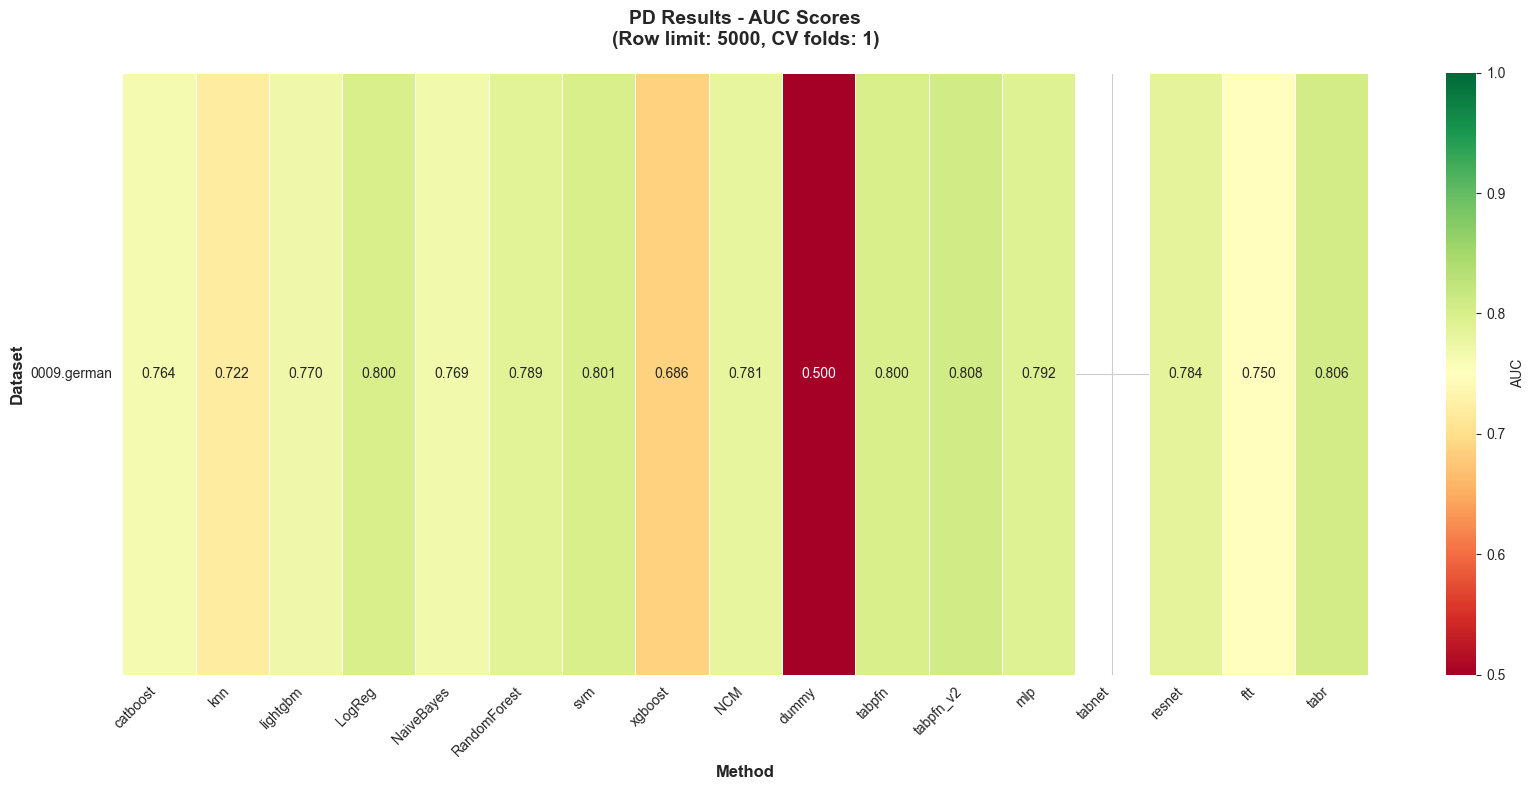

✓ LGD heatmap saved to: c:\Users\U0152019\OneDrive - KU Leuven\PhD Documents\Projects\1. TabPFN\TabPFNCredit\results\experiment_small\lgd_heatmap_20251219_101927.png


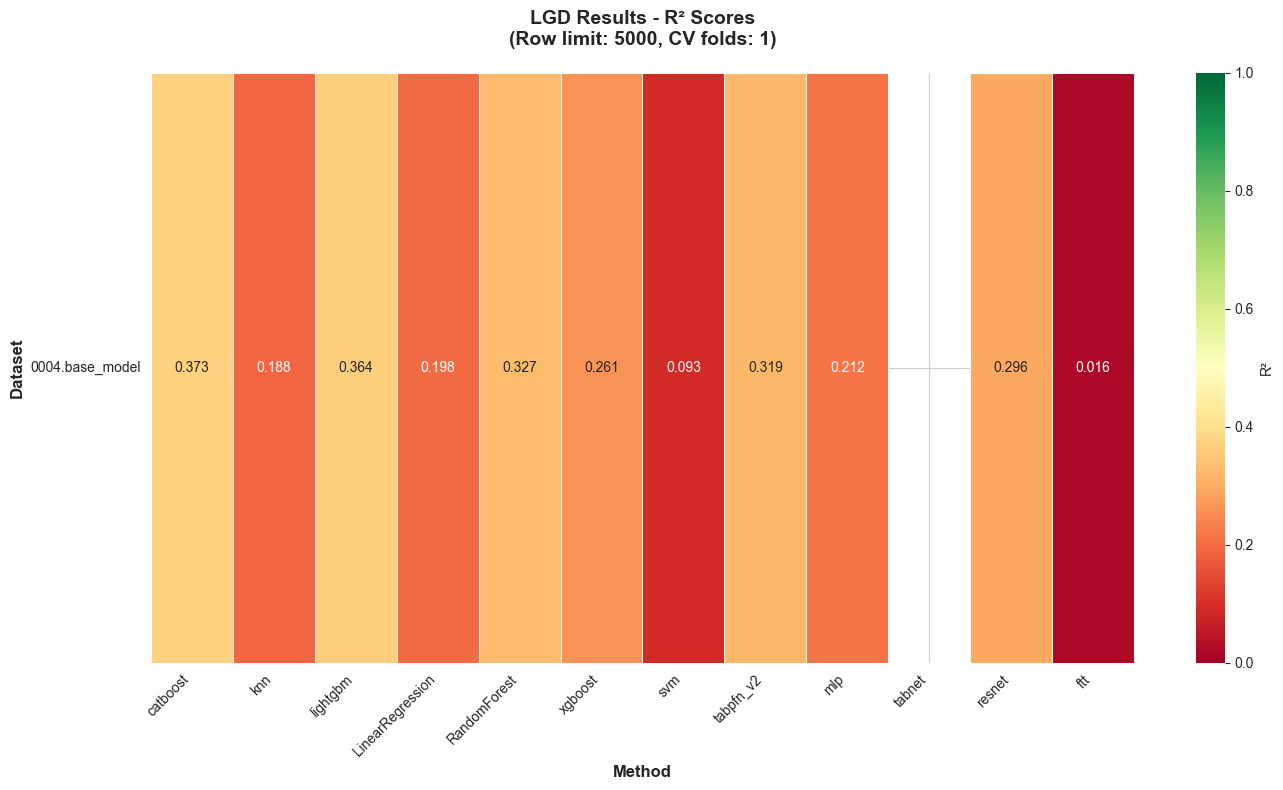


 EXPERIMENT COMPLETE
  Timestamp: 2025-12-19 10:19:29.515625
  Results saved in: c:\Users\U0152019\OneDrive - KU Leuven\PhD Documents\Projects\1. TabPFN\TabPFNCredit\results\experiment_small


In [ ]:
# =============================================================================
# EXPERIMENT SMALL - Quick Benchmarking (CPU MODE)
# =============================================================================

# FORCE CPU MODE (add this FIRST)
import os
os.environ['CUDA_VISIBLE_DEVICES'] = ''

import sys
from pathlib import Path
import pickle
import json
import pandas as pd
import numpy as np
from datetime import datetime
from tqdm.auto import tqdm
import warnings
warnings.filterwarnings('ignore')

# Add project root to path
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

print(f"Project root: {PROJECT_ROOT}")

# Verify CPU mode
import torch
print(f"\n{'='*80}")
print(f" COMPUTE MODE")
print(f"{'='*80}")
print(f"  CUDA Available: {torch.cuda.is_available()}")
print(f"  Device: CPU (forced)")
print(f"{'='*80}\n")

# -----------------------------------------------------------------------------
# CONFIGURATION
# -----------------------------------------------------------------------------

# --- EXPERIMENT SETTINGS ---
ROW_LIMIT = 5000       # Max rows per dataset (null for all)
CV_SPLITS = 1          # 1 = Single split, >1 = Cross Validation
MAX_EPOCHS = 15        # Epochs for deep learning models
BATCH_SIZE = 1024
TUNE = False           # Run Hyperparameter Optimization?
SEED = 42
TEST_SIZE = 0.2
VAL_SIZE = 0.2

# --- DATASET SELECTION ---
# Comment out datasets you do not want to run

SELECTED_PD_DATASETS = [
    "0001.gmsc",
    "0002.taiwan_creditcard",
    "0003.vehicle_loan",
    "0004.lendingclub",
    "0005.case_study",
    "0006.myhom",
    "0007.hackerearth",
    "0008.cobranded",
    "0009.german",             
    "0010.bank_status",
    "0011.thomas",
    "0012.loan_default",
    "0013.home_credit",
    "0014.hmeq",
    "0015.algorithmwatch",
]

SELECTED_LGD_DATASETS = [
    "0001.heloc",
    "0002.loss2",
    "0003.axa",
    "0004.base_model",         
    "0005.base_modelisation",
    "0006.lgd_freddie",
    "0007.lgd_lendingclub",
]

# --- METHOD SELECTION ---
# Comment out methods you do not want to run

SELECTED_PD_METHODS = [
    # --- Classical Machine Learning ---
    "catboost",
    "knn",
    "lightgbm",
    "LogReg",
    "NaiveBayes",
    "RandomForest",
    "svm",
    "xgboost",
    "NCM",
    "dummy",

    # --- Foundation Models ---
    "tabpfn",
    "tabpfn_v2",
    # "tabpfn_real",

    # --- Deep Learning / Transformers ---
    "mlp",
    "tabnet",
    "resnet",
    "ftt",
    # "node",
    # "saint",
    # "tabtransformer",
    # "autoint",
    # "danets",
    # "snn",
    # "dcn2",
    # "tabcaps",
    # "tangos",
    # "ptarl",
    # "switchtab",
    # "dnnr",
    # "modernNCA",
    # "hyperfast",
    # "bishop",
    # "realmlp",
    # "protogate",
    # "mlp_plr",
    # "excelformer",
    # "grande",
    # "amformer",
    # "tabptm",
    # "trompt",
    # "tabm",
    # "t2gformer",
    # "tabautopnpnet",
    # "tabicl",
    # "grownet",
    "tabr",
    # "limix",
    # "mitra",
]

SELECTED_LGD_METHODS = [
    # --- Classical Machine Learning ---
    "catboost",
    "knn",
    "lightgbm",
    "LinearRegression",
    "RandomForest",
    "xgboost",
    "svm",

    # --- Foundation Models ---
    "tabpfn_v2",

    # --- Deep Learning / Transformers ---
    "mlp",
    "tabnet",
    "resnet",
    "ftt",
    # "node",
    # "saint",
    # "tabtransformer",
    # "autoint",
    # "danets",
    # "snn",
    # "dcn2",
    # "tabcaps",
    # "tangos",
    # "ptarl",
    # "switchtab",
    # "dnnr",
    # "modernNCA",
    # "hyperfast",
    # "bishop",
    # "realmlp",
    # "protogate",
    # "mlp_plr",
    # "excelformer",
    # "grande",
    # "amformer",
    # "tabptm",
    # "trompt",
    # "tabm",
    # "t2gformer",
    # "tabautopnpnet",
    # "tabicl",
    # "grownet",
    # "limix",
    # "mitra",
]

# Optional: List of methods to explicitly exclude even if selected above
EXCLUDE_METHODS = [] 

print(f"\n{'='*80}")
print(f" EXPERIMENT SMALL - Quick Benchmarking")
print(f"{'='*80}")
print(f"  Row limit:       {ROW_LIMIT}")
print(f"  CV splits:       {CV_SPLITS}")
print(f"  Max epochs:      {MAX_EPOCHS}")
print(f"  HPO:             {TUNE}")
print(f"  Device:          CPU")
print(f"  Excluded:        {', '.join(EXCLUDE_METHODS) if EXCLUDE_METHODS else 'None'}")
print(f"{'='*80}\n")

# Apply exclusions
pd_methods = [m for m in SELECTED_PD_METHODS if m not in EXCLUDE_METHODS]
lgd_methods = [m for m in SELECTED_LGD_METHODS if m not in EXCLUDE_METHODS]
pd_datasets = SELECTED_PD_DATASETS
lgd_datasets = SELECTED_LGD_DATASETS

print(f"PD Datasets ({len(pd_datasets)}): {pd_datasets}")
print(f"LGD Datasets ({len(lgd_datasets)}): {lgd_datasets}")
print()
print(f"PD Methods ({len(pd_methods)}): {pd_methods}")
print(f"LGD Methods ({len(lgd_methods)}): {lgd_methods}")
print()

# -----------------------------------------------------------------------------
# RUN EXPERIMENTS
# -----------------------------------------------------------------------------

from src.methods.method_runner import run_talent_method

def run_single_experiment(task, dataset, method):
    """Run a single method-dataset combination and extract metric."""
    try:
        results = run_talent_method(
            task=task,
            dataset=dataset,
            test_size=TEST_SIZE,
            val_size=VAL_SIZE,
            cv_splits=CV_SPLITS,
            seed=SEED,
            row_limit=ROW_LIMIT,
            method=method,
            max_epoch=MAX_EPOCHS,
            batch_size=BATCH_SIZE,
            tune=TUNE,
            n_trials=20,
            early_stopping=True,
            early_stopping_patience=10,
            verbose=False,
        )
        
        # Determine the first key (might be 0 or 1 depending on cv_splits)
        fold_keys = list(results.keys())
        if not fold_keys:
             print(f"  WARNING: No results returned for {method} on {dataset}")
             return np.nan
             
        first_fold = fold_keys[0]
        fold_results = results[first_fold]
        metrics = fold_results['metrics']
        
        if task == 'pd':
            metric = metrics.get('AUC', np.nan)
        else:
            metric = metrics.get('R2', np.nan)
        
        return metric
            
    except Exception as e:
        print(f"  ERROR: {method} on {dataset} - {str(e)[:100]}")
        return np.nan


def run_task_experiments(task, datasets, methods):
    """Run all method-dataset combinations for a task."""
    metric_name = "AUC" if task == 'pd' else "R2"
    
    print(f"\n{'='*80}")
    print(f" Running {task.upper()} Experiments")
    print(f"{'='*80}")
    print(f"  Datasets: {len(datasets)}")
    print(f"  Methods:  {len(methods)}")
    print(f"  Total:    {len(datasets) * len(methods)} experiments")
    print(f"  Metric:   {metric_name}")
    print(f"{'='*80}\n")
    
    if len(datasets) == 0 or len(methods) == 0:
        print("No experiments to run for this task.")
        return pd.DataFrame()

    results_matrix = pd.DataFrame(index=datasets, columns=methods, dtype=float)
    total_experiments = len(datasets) * len(methods)
    
    with tqdm(total=total_experiments, desc=f"{task.upper()} Progress") as pbar:
        for dataset in datasets:
            for method in methods:
                pbar.set_description(f"{task.upper()}: {dataset[:20]:20s} + {method[:15]:15s}")
                metric = run_single_experiment(task, dataset, method)
                results_matrix.loc[dataset, method] = metric
                pbar.update(1)
    
    return results_matrix


# Run experiments
pd_results = run_task_experiments('pd', pd_datasets, pd_methods)
lgd_results = run_task_experiments('lgd', lgd_datasets, lgd_methods)

print("\n✓ All experiments completed!")

# -----------------------------------------------------------------------------
# DISPLAY RESULTS
# -----------------------------------------------------------------------------

if not pd_results.empty:
    print(f"\n{'='*80}")
    print(f" PD RESULTS (AUC)")
    print(f"{'='*80}\n")
    print(pd_results.to_string())

if not lgd_results.empty:
    print(f"\n{'='*80}")
    print(f" LGD RESULTS (R²)")
    print(f"{'='*80}\n")
    print(lgd_results.to_string())

# -----------------------------------------------------------------------------
# SAVE RESULTS
# -----------------------------------------------------------------------------

output_dir = PROJECT_ROOT / 'results' / 'experiment_small'
output_dir.mkdir(parents=True, exist_ok=True)

timestamp = datetime.now().strftime('%Y%m%d_%H%M%S')

if not pd_results.empty:
    pd_csv_path = output_dir / f"pd_results_auc_{timestamp}.csv"
    pd_results.to_csv(pd_csv_path)
    print(f"\n✓ PD results saved to: {pd_csv_path}")

if not lgd_results.empty:
    lgd_csv_path = output_dir / f"lgd_results_r2_{timestamp}.csv"
    lgd_results.to_csv(lgd_csv_path)
    print(f"✓ LGD results saved to: {lgd_csv_path}")

config_summary = {
    'timestamp': timestamp,
    'settings': {
        'row_limit': ROW_LIMIT,
        'cv_splits': CV_SPLITS,
        'max_epochs': MAX_EPOCHS,
        'batch_size': BATCH_SIZE,
        'tune': TUNE,
        'seed': SEED,
        'test_size': TEST_SIZE,
        'val_size': VAL_SIZE,
        'excluded_methods': EXCLUDE_METHODS,
    },
    'compute': {
        'device': 'CPU',
        'cuda_available': False,
    },
    'datasets': {
        'pd': pd_datasets,
        'lgd': lgd_datasets,
    },
    'methods': {
        'pd': pd_methods,
        'lgd': lgd_methods,
    },
    'metrics': {
        'pd': 'AUC',
        'lgd': 'R²'
    },
    'n_experiments': (len(pd_datasets) * len(pd_methods)) + (len(lgd_datasets) * len(lgd_methods)),
}

config_path = output_dir / f"config_{timestamp}.json"
with open(config_path, 'w') as f:
    json.dump(config_summary, f, indent=2)
print(f"✓ Configuration saved to: {config_path}")

# -----------------------------------------------------------------------------
# SUMMARY STATISTICS
# -----------------------------------------------------------------------------

print(f"\n{'='*80}")
print(f" SUMMARY STATISTICS")
print(f"{'='*80}")

if len(pd_results) > 0 and not pd_results.empty:
    print(f"\n[PD TASK - AUC]")
    print(f"  Best method overall:     {pd_results.mean(axis=0).idxmax()} (Avg: {pd_results.mean(axis=0).max():.4f})")
    print(f"  Worst method overall:    {pd_results.mean(axis=0).idxmin()} (Avg: {pd_results.mean(axis=0).min():.4f})")
    print(f"  Hardest dataset:         {pd_results.mean(axis=1).idxmin()} (Avg: {pd_results.mean(axis=1).min():.4f})")
    print(f"  Easiest dataset:         {pd_results.mean(axis=1).idxmax()} (Avg: {pd_results.mean(axis=1).max():.4f})")
    print(f"  Experiments completed:   {pd_results.notna().sum().sum()} / {pd_results.size}")
    print(f"  Failed experiments:      {pd_results.isna().sum().sum()}")

if len(lgd_results) > 0 and not lgd_results.empty:
    print(f"\n[LGD TASK - R²]")
    print(f"  Best method overall:     {lgd_results.mean(axis=0).idxmax()} (Avg: {lgd_results.mean(axis=0).max():.4f})")
    print(f"  Worst method overall:    {lgd_results.mean(axis=0).idxmin()} (Avg: {lgd_results.mean(axis=0).min():.4f})")
    print(f"  Hardest dataset:         {lgd_results.mean(axis=1).idxmin()} (Avg: {lgd_results.mean(axis=1).min():.4f})")
    print(f"  Easiest dataset:         {lgd_results.mean(axis=1).idxmax()} (Avg: {lgd_results.mean(axis=1).max():.4f})")
    print(f"  Experiments completed:   {lgd_results.notna().sum().sum()} / {lgd_results.size}")
    print(f"  Failed experiments:      {lgd_results.isna().sum().sum()}")

# -----------------------------------------------------------------------------
# VISUALIZATIONS
# -----------------------------------------------------------------------------

import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams['figure.dpi'] = 100

if len(pd_results) > 0 and not pd_results.empty:
    fig, ax = plt.subplots(figsize=(max(14, len(pd_methods) * 1.0), 
                                     max(8, len(pd_datasets) * 0.5)))
    
    sns.heatmap(
        pd_results.astype(float), 
        annot=True, 
        fmt='.3f', 
        cmap='RdYlGn',
        center=0.75, 
        vmin=0.5, 
        vmax=1.0,
        cbar_kws={'label': 'AUC'},
        linewidths=0.5,
        ax=ax
    )
    
    ax.set_title(
        f'PD Results - AUC Scores\n(Row limit: {ROW_LIMIT}, CV folds: {CV_SPLITS})',
        fontsize=14,
        fontweight='bold',
        pad=20
    )
    ax.set_xlabel('Method', fontsize=12, fontweight='bold')
    ax.set_ylabel('Dataset', fontsize=12, fontweight='bold')
    
    plt.xticks(rotation=45, ha='right')
    plt.yticks(rotation=0)
    plt.tight_layout()
    
    heatmap_path = output_dir / f"pd_heatmap_{timestamp}.png"
    plt.savefig(heatmap_path, dpi=300, bbox_inches='tight')
    print(f"\n✓ PD heatmap saved to: {heatmap_path}")
    plt.show()

if len(lgd_results) > 0 and not lgd_results.empty:
    fig, ax = plt.subplots(figsize=(max(14, len(lgd_methods) * 1.0),
                                     max(8, len(lgd_datasets) * 0.5)))
    
    sns.heatmap(
        lgd_results.astype(float),
        annot=True,
        fmt='.3f',
        cmap='RdYlGn',
        center=0.5,
        vmin=0.0,
        vmax=1.0,
        cbar_kws={'label': 'R²'},
        linewidths=0.5,
        ax=ax
    )
    
    ax.set_title(
        f'LGD Results - R² Scores\n(Row limit: {ROW_LIMIT}, CV folds: {CV_SPLITS})',
        fontsize=14,
        fontweight='bold',
        pad=20
    )
    ax.set_xlabel('Method', fontsize=12, fontweight='bold')
    ax.set_ylabel('Dataset', fontsize=12, fontweight='bold')
    
    plt.xticks(rotation=45, ha='right')
    plt.yticks(rotation=0)
    plt.tight_layout()
    
    heatmap_path = output_dir / f"lgd_heatmap_{timestamp}.png"
    plt.savefig(heatmap_path, dpi=300, bbox_inches='tight')
    print(f"✓ LGD heatmap saved to: {heatmap_path}")
    plt.show()

print(f"\n{'='*80}")
print(f" EXPERIMENT COMPLETE")
print(f"{'='*80}")
print(f"  Timestamp: {datetime.now()}")
print(f"  Results saved in: {output_dir}")
print(f"{'='*80}")